# Hotel Booking Cancellation Prediction

## Goal

The goal of this notebook is to build a supervised machine learning model that predicts whether a hotel booking will be cancelled.

This is a practical classification problem because hotel cancellations affect revenue, room planning, staffing, and booking management.

The notebook covers:

- Loading a Kaggle dataset with KaggleHub
- Cleaning hotel booking data
- Exploratory data analysis
- Feature engineering
- Train-test splitting
- Preprocessing numerical and categorical features
- Building baseline and machine learning models
- Comparing Logistic Regression, Random Forest, and HistGradientBoosting
- Evaluating ROC-AUC, PR-AUC, precision, recall, F1-score, and confusion matrix
- Tuning the classification threshold
- Interpreting feature importance
- Producing business-style insights

The main objective is not only to maximize accuracy, but to understand which bookings are more likely to cancel and how the model could support hotel decision-making.

In [1]:
import os
import warnings
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## Setup

This notebook uses scikit-learn for supervised classification.

The task is binary classification because the target variable has two outcomes:

- `0`: booking was not cancelled
- `1`: booking was cancelled

Several models are compared so that the final result is not based on only one algorithm.

In [2]:
path = kagglehub.dataset_download("jessemostipak/hotel-booking-demand")

print("Dataset downloaded to:", path)
print("Files:")
print(os.listdir(path))

100%|██████████| 1.25M/1.25M [00:01<00:00, 1.28MB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\jessemostipak\hotel-booking-demand\versions\1
Files:
['hotel_bookings.csv']


In [3]:
path = Path(path)

csv_files = list(path.glob("*.csv"))
csv_files

[WindowsPath('C:/Users/ADMIN/.cache/kagglehub/datasets/jessemostipak/hotel-booking-demand/versions/1/hotel_bookings.csv')]

In [4]:
df = pd.read_csv(csv_files[0])

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## Dataset

This notebook uses the Hotel Booking Demand dataset from Kaggle.

The dataset contains booking information for city hotels and resort hotels.

Each row represents one hotel booking. The target variable is `is_canceled`, which indicates whether the booking was cancelled.

The features include booking timing, customer information, stay duration, deposit type, market segment, room type, special requests, and other booking-related variables.

In [5]:
df.describe(include="all")

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
count,119390,119390.000000,119390.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390,118902,119390,119390,119390.000000,119390.000000,119390.000000,119390,119390,119390.000000,119390,103050.000000,6797.000000,119390.000000,119390,119390.000000,119390.000000,119390.000000,119390,119390
unique,2,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,177,8,5,NaN,NaN,NaN,10,12,NaN,3,NaN,NaN,NaN,4,NaN,NaN,NaN,3,926
top,City Hotel,NaN,NaN,NaN,August,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BB,PRT,Online TA,TA/TO,NaN,NaN,NaN,A,A,NaN,No Deposit,NaN,NaN,NaN,Transient,NaN,NaN,NaN,Check-Out,2015-10-21
freq,79330,NaN,NaN,NaN,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92310,48590,56477,97870,NaN,NaN,NaN,85994,74053,NaN,104641,NaN,NaN,NaN,89613,NaN,NaN,NaN,75166,1461
mean,NaN,0.370416,104.011416,2016.156554,NaN,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,NaN,NaN,NaN,NaN,0.031912,0.087118,0.137097,NaN,NaN,0.221124,NaN,86.693382,189.266735,2.321149,NaN,101.831122,0.062518,0.571363,NaN,NaN
std,NaN,0.482918,106.863097,0.707476,NaN,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,NaN,NaN,NaN,NaN,0.175767,0.844336,1.497437,NaN,NaN,0.652306,NaN,110.774548,131.655015,17.594721,NaN,50.535790,0.245291,0.792798,NaN,NaN
min,NaN,0.000000,0.000000,2015.000000,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,1.000000,6.000000,0.000000,NaN,-6.380000,0.000000,0.000000,NaN,NaN
25%,NaN,0.000000,18.000000,2016.000000,NaN,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,9.000000,62.000000,0.000000,NaN,69.290000,0.000000,0.000000,NaN,NaN
50%,NaN,0.000000,69.000000,2016.000000,NaN,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,14.000000,179.000000,0.000000,NaN,94.575000,0.000000,0.000000,NaN,NaN
75%,NaN,1.000000,160.000000,2017.000000,NaN,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,229.000000,270.000000,0.000000,NaN,126.000000,0.000000,1.000000,NaN,NaN


In [6]:
df["is_canceled"].value_counts(normalize=True)

is_canceled
0    0.629584
1    0.370416
Name: proportion, dtype: float64

## Initial Data Inspection

The dataset contains 119,390 hotel bookings and 32 columns.

The target variable is `is_canceled`.

The cancellation distribution is:

- Not cancelled: 75,166 bookings, or 62.96%
- Cancelled: 44,224 bookings, or 37.04%

The dataset contains some missing values. The main missing columns are `company`, `agent`, `country`, and `children`. These missing values are handled later through the preprocessing pipeline.

The dataset contains both numerical and categorical features, including hotel type, lead time, arrival date information, length of stay, customer type, market segment, deposit type, room type, special requests, and previous booking history.

The target distribution is moderately imbalanced because non-cancelled bookings are more common than cancelled bookings. This means accuracy alone is not enough for evaluation, so the notebook also uses precision, recall, F1-score, ROC-AUC, and PR-AUC.

In [7]:
hotel_cancel_rate = (
    df.groupby("hotel")["is_canceled"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

hotel_cancel_rate

,count,mean
hotel,,
City Hotel,79330,0.417270
Resort Hotel,40060,0.277634


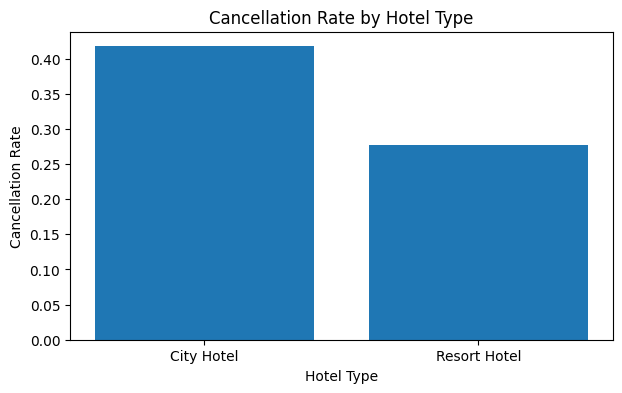

In [8]:
plt.figure(figsize=(7, 4))
plt.bar(hotel_cancel_rate.index, hotel_cancel_rate["mean"])
plt.title("Cancellation Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Cancellation Rate")
plt.show()

In [9]:
deposit_cancel_rate = (
    df.groupby("deposit_type")["is_canceled"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

deposit_cancel_rate

,count,mean
deposit_type,,
Non Refund,14587,0.993624
No Deposit,104641,0.283770
Refundable,162,0.222222


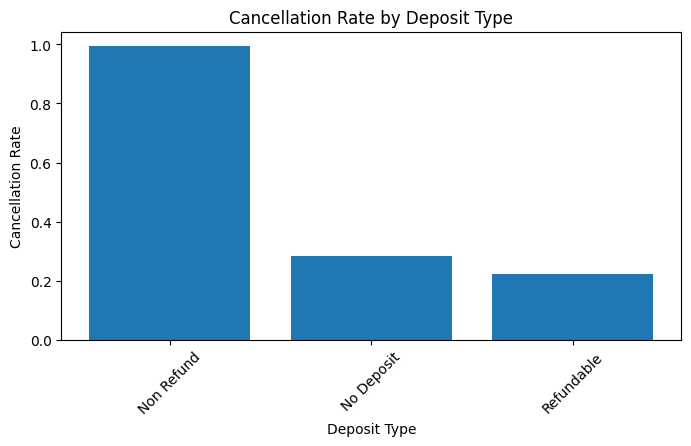

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(deposit_cancel_rate.index, deposit_cancel_rate["mean"])
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Cancellation Rate")
plt.xticks(rotation=45)
plt.show()

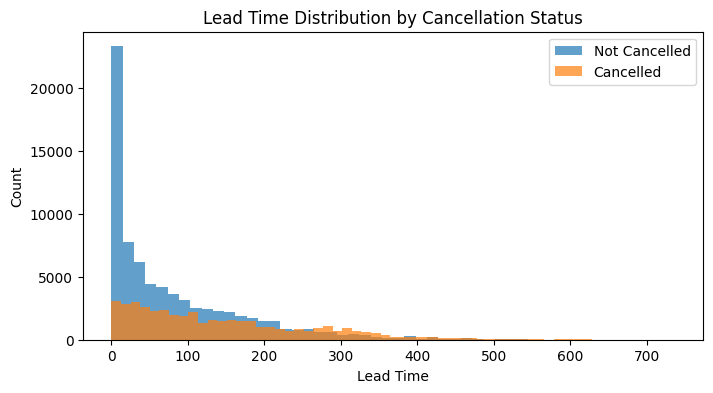

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["is_canceled"] == 0]["lead_time"], bins=50, alpha=0.7, label="Not Cancelled")
plt.hist(df[df["is_canceled"] == 1]["lead_time"], bins=50, alpha=0.7, label="Cancelled")
plt.title("Lead Time Distribution by Cancellation Status")
plt.xlabel("Lead Time")
plt.ylabel("Count")
plt.legend()
plt.show()

In [12]:
special_request_cancel_rate = (
    df.groupby("total_of_special_requests")["is_canceled"]
    .agg(["count", "mean"])
)

special_request_cancel_rate

,count,mean
total_of_special_requests,,
0,70318,0.477204
1,33226,0.220249
2,12969,0.220989
3,2497,0.178614
4,340,0.105882
5,40,0.050000


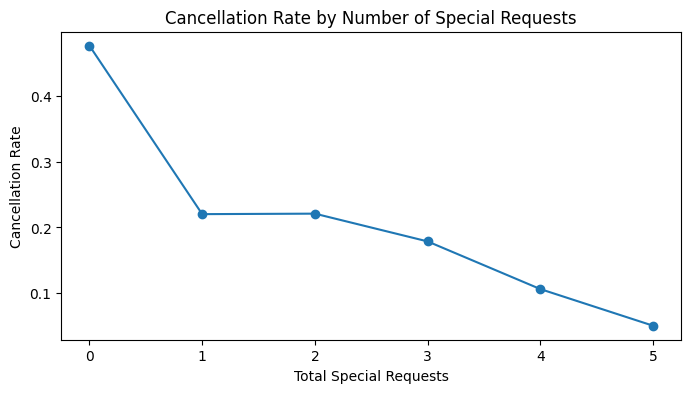

In [13]:
plt.figure(figsize=(8, 4))
plt.plot(
    special_request_cancel_rate.index,
    special_request_cancel_rate["mean"],
    marker="o"
)
plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Total Special Requests")
plt.ylabel("Cancellation Rate")
plt.show()

## Exploratory Data Analysis

The EDA section explores how cancellation rate changes across important booking features.

City Hotel bookings had a higher cancellation rate than Resort Hotel bookings. City Hotel had a cancellation rate of 41.73%, while Resort Hotel had a cancellation rate of 27.76%.

Deposit type showed one of the strongest differences. Non Refund bookings had a cancellation rate of 99.36%, while No Deposit bookings had a cancellation rate of 28.38%. Refundable bookings had a cancellation rate of 22.22%, but this group was very small with only 162 bookings.

Lead time also appears important. Bookings with longer lead times are more likely to be cancelled because customers who book far in advance have more time for their plans to change.

Special requests were strongly associated with lower cancellation rates. Bookings with no special requests had a cancellation rate of 47.72%, while bookings with five special requests had a cancellation rate of only 5.00%.

Overall, the EDA suggests that cancellation risk is related to booking commitment, timing, customer behaviour, and booking conditions.

In [14]:
df_model = df.copy()

df_model["total_guests"] = (
    df_model["adults"].fillna(0)
    + df_model["children"].fillna(0)
    + df_model["babies"].fillna(0)
)

df_model["total_stay_nights"] = (
    df_model["stays_in_weekend_nights"]
    + df_model["stays_in_week_nights"]
)

df_model["has_previous_cancellation"] = (
    df_model["previous_cancellations"] > 0
).astype(int)

df_model["has_special_request"] = (
    df_model["total_of_special_requests"] > 0
).astype(int)

df_model["has_parking"] = (
    df_model["required_car_parking_spaces"] > 0
).astype(int)

df_model[[
    "total_guests",
    "total_stay_nights",
    "has_previous_cancellation",
    "has_special_request",
    "has_parking"
]].head()

,total_guests,total_stay_nights,has_previous_cancellation,has_special_request,has_parking
0,2.0,0,0,0,0
1,2.0,0,0,0,0
2,1.0,1,0,0,0
3,1.0,1,0,0,0
4,2.0,2,0,1,0


In [15]:
target = "is_canceled"

drop_cols = [
    "is_canceled",
    "reservation_status",
    "reservation_status_date"
]

X = df_model.drop(columns=drop_cols)
y = df_model[target]

X.shape, y.shape

((119390, 34), (119390,))

## Feature Engineering

Several new features are created to make the booking information more useful for modelling.

The engineered features are:

- `total_guests`: total number of adults, children, and babies
- `total_stay_nights`: total length of stay
- `has_previous_cancellation`: whether the customer has cancelled before
- `has_special_request`: whether the booking has at least one special request
- `has_parking`: whether the customer requested parking

The columns `reservation_status` and `reservation_status_date` are removed because they leak information about the final booking outcome.

Removing leakage features is essential because the model should only use information that would be available before the cancellation outcome is known.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("Train target distribution:")
print(y_train.value_counts(normalize=True))

print("Test target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (95512, 34)
Test shape: (23878, 34)
Train target distribution:
is_canceled
0    0.629586
1    0.370414
Name: proportion, dtype: float64
Test target distribution:
is_canceled
0    0.629575
1    0.370425
Name: proportion, dtype: float64


## Train-Test Split

The data is split into training and test sets.

Stratification is used so that the cancellation rate is similar in both sets.

The training set is used to fit the models, while the test set is kept separate for final evaluation.

In [17]:
numeric_features = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_guests', 'total_stay_nights', 'has_previous_cancellation', 'has_special_request', 'has_parking']
Categorical features: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## Preprocessing

The dataset contains both numerical and categorical features.

Numerical features are median-imputed and standardized.

Categorical features are imputed using the most frequent value and then one-hot encoded.

The preprocessing steps are placed inside a pipeline so that the same transformations are applied consistently during training, cross-validation, and testing.

In [19]:
models = {
    "Dummy Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=200,
        max_leaf_nodes=31,
        l2_regularization=0.1,
        random_state=42
    )
}

In [23]:
scoring = {
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rows = []

for model_name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    
    cv_rows.append({
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "pr_auc_mean": scores["test_average_precision"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "precision_mean": scores["test_precision"].mean(),
        "recall_mean": scores["test_recall"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("roc_auc_mean", ascending=False)
cv_results

,model,accuracy_mean,roc_auc_mean,pr_auc_mean,f1_mean,precision_mean,recall_mean
3,HistGradientBoosting,0.878769,0.951840,0.929492,0.831317,0.857749,0.806495
2,Random Forest,0.882099,0.951088,0.929677,0.838711,0.850184,0.827553
1,Logistic Regression,0.815301,0.900964,0.864622,0.759621,0.733339,0.787897
0,Dummy Baseline,0.629586,0.500000,0.370414,0.000000,0.000000,0.000000


## Model Comparison with Cross-Validation

Several supervised classification models are compared using 5-fold stratified cross-validation.

The models are:

- Dummy baseline
- Logistic Regression
- Random Forest
- HistGradientBoosting

The dummy baseline achieved ROC-AUC of 0.5000 and F1-score of 0.0000, showing that it provides no useful cancellation prediction ability.

Logistic Regression performed much better than the dummy baseline, with ROC-AUC of 0.9010, PR-AUC of 0.8646, and F1-score of 0.7596.

Random Forest achieved strong results, with ROC-AUC of 0.9511, PR-AUC of 0.9297, and F1-score of 0.8387.

HistGradientBoosting achieved the highest ROC-AUC, with ROC-AUC of 0.9518, PR-AUC of 0.9295, and F1-score of 0.8313.

Random Forest had the highest F1-score and PR-AUC, while HistGradientBoosting had the highest ROC-AUC. Since the final model selection uses ROC-AUC, HistGradientBoosting is selected as the final model.

This comparison shows that tree-based models are much stronger than Logistic Regression for this dataset, likely because cancellation behaviour depends on nonlinear interactions between booking features.

In [24]:
best_model_name = cv_results.iloc[0]["model"]
best_model_name

'HistGradientBoosting'

In [25]:
final_model = models[best_model_name]

final_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", final_model)
])

final_pipe.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Final Model Training

The final model is selected based on cross-validation ROC-AUC.

The selected model is HistGradientBoosting.

HistGradientBoosting achieved the highest cross-validation ROC-AUC of 0.9518, making it the strongest model for ranking bookings by cancellation risk.

The final pipeline includes preprocessing and the HistGradientBoosting model. It is trained on the full training set and then evaluated on the untouched test set.

In [26]:
y_pred = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "pr_auc": average_precision_score(y_test, y_proba)
}

test_metrics

{'accuracy': 0.8797637993131753,
 'precision': 0.8631169462679309,
 'recall': 0.8027133973996609,
 'f1': 0.8318200456915237,
 'roc_auc': 0.9526778077112958,
 'pr_auc': 0.9298919675086126}

In [27]:
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.8885    0.9251    0.9064     15033
           1     0.8631    0.8027    0.8318      8845

    accuracy                         0.8798     23878
   macro avg     0.8758    0.8639    0.8691     23878
weighted avg     0.8791    0.8798    0.8788     23878



In [28]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["Actual Not Cancelled", "Actual Cancelled"],
    columns=["Predicted Not Cancelled", "Predicted Cancelled"]
)

cm_df

,Predicted Not Cancelled,Predicted Cancelled
Actual Not Cancelled,13907,1126
Actual Cancelled,1745,7100


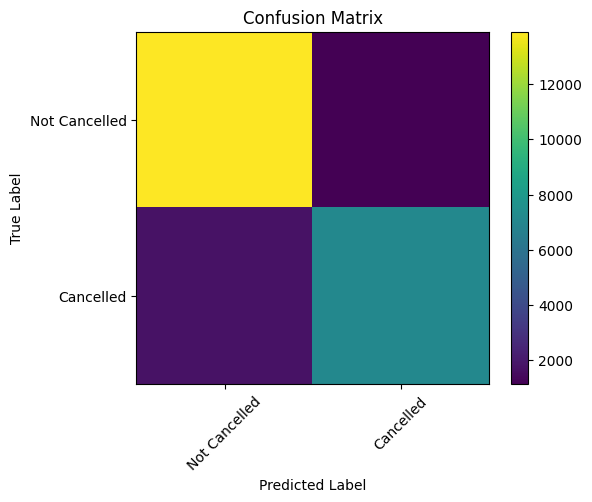

In [29]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Not Cancelled", "Cancelled"], rotation=45)
plt.yticks(tick_marks, ["Not Cancelled", "Cancelled"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Test Set Evaluation

The final HistGradientBoosting model is evaluated on the untouched test set.

The test set results are:

- Accuracy: 0.8798
- Precision: 0.8631
- Recall: 0.8027
- F1-score: 0.8318
- ROC-AUC: 0.9527
- PR-AUC: 0.9299

The model correctly classified 13,907 non-cancelled bookings and 7,100 cancelled bookings.

The confusion matrix also shows 1,126 false positives and 1,745 false negatives.

A false positive means the model predicted a booking would be cancelled, but it was not cancelled. A false negative means the model predicted a booking would not be cancelled, but it was cancelled.

The model performs strongly overall, especially in terms of ROC-AUC and PR-AUC. This means the predicted cancellation probabilities are useful for ranking bookings by cancellation risk, not only for producing a binary prediction.

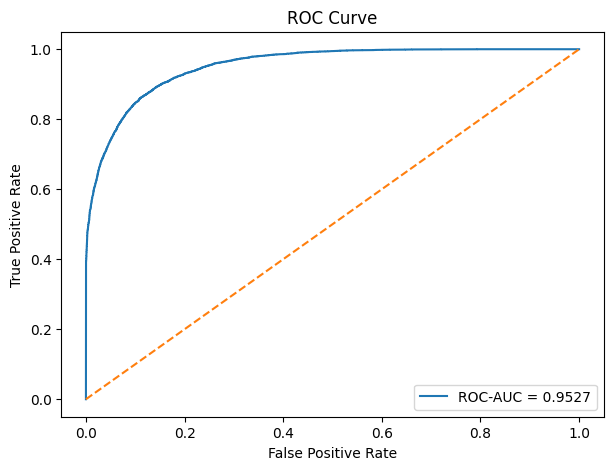

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

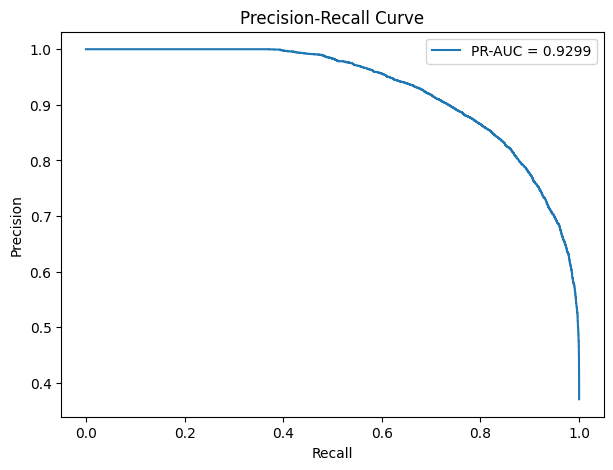

In [31]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {test_metrics['pr_auc']:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

## ROC and Precision-Recall Curves

The ROC curve shows the trade-off between true positive rate and false positive rate across different thresholds.

The Precision-Recall curve focuses on performance for the cancelled booking class.

These curves are useful because the default classification threshold of 0.5 may not be the best threshold for a business decision.

In [32]:
threshold_rows = []

for threshold in np.arange(0.1, 0.91, 0.05):
    pred_threshold = (y_proba >= threshold).astype(int)
    
    threshold_rows.append({
        "threshold": threshold,
        "predicted_cancellations": pred_threshold.sum(),
        "precision": precision_score(y_test, pred_threshold, zero_division=0),
        "recall": recall_score(y_test, pred_threshold, zero_division=0),
        "f1": f1_score(y_test, pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df

,threshold,predicted_cancellations,precision,recall,f1
0,0.10,14474,0.601838,0.984850,0.747116
1,0.15,13267,0.648225,0.972301,0.777858
2,0.20,12283,0.688187,0.955681,0.800170
3,0.25,11444,0.722387,0.934652,0.814924
4,0.30,10693,0.756102,0.914076,0.827618
5,0.35,9983,0.788240,0.889655,0.835883
6,0.40,9347,0.817161,0.863539,0.839710
7,0.45,8741,0.842695,0.832787,0.837712
8,0.50,8226,0.863117,0.802713,0.831820
9,0.55,7774,0.879599,0.773092,0.822914


In [33]:
best_f1_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
best_f1_row

threshold                     0.400000
predicted_cancellations    9347.000000
precision                     0.817161
recall                        0.863539
f1                            0.839710
Name: 6, dtype: float64

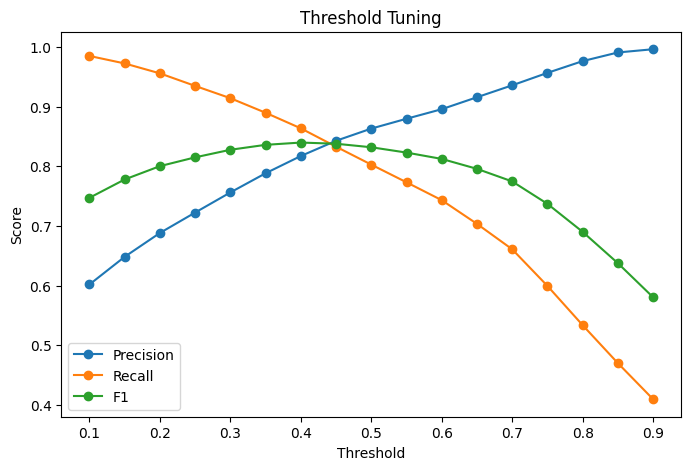

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.title("Threshold Tuning")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

## Threshold Tuning

The default classification threshold of 0.5 is not always the best threshold for a business decision.

A lower threshold predicts more bookings as likely cancellations. This usually increases recall but lowers precision.

A higher threshold predicts fewer bookings as likely cancellations. This usually increases precision but lowers recall.

The best F1-score was achieved at a threshold of 0.40.

At this threshold:

- Predicted cancellations: 9,347
- Precision: 0.8172
- Recall: 0.8635
- F1-score: 0.8397

Compared with the default 0.5 threshold, the 0.4 threshold increases recall from 0.8027 to 0.8635. This means the model catches more actual cancellations.

The trade-off is that precision decreases from 0.8631 to 0.8172, meaning more non-cancelled bookings are incorrectly flagged as cancellation risks.

For hotel operations, this threshold may be useful if the goal is to catch more likely cancellations, even if it creates more false alarms.

In [35]:
sample_size = min(5000, len(X_test))

X_test_sample = X_test.sample(sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

perm_result = permutation_importance(
    final_pipe,
    X_test_sample,
    y_test_sample,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
12,country,0.088702,0.003149
21,deposit_type,0.082280,0.003402
13,market_segment,0.064498,0.003154
22,agent,0.052842,0.002392
27,required_car_parking_spaces,0.038157,0.005395
1,lead_time,0.035670,0.002850
2,arrival_date_year,0.025630,0.001788
28,total_of_special_requests,0.025104,0.001229
16,previous_cancellations,0.025037,0.001363
25,customer_type,0.019159,0.000702


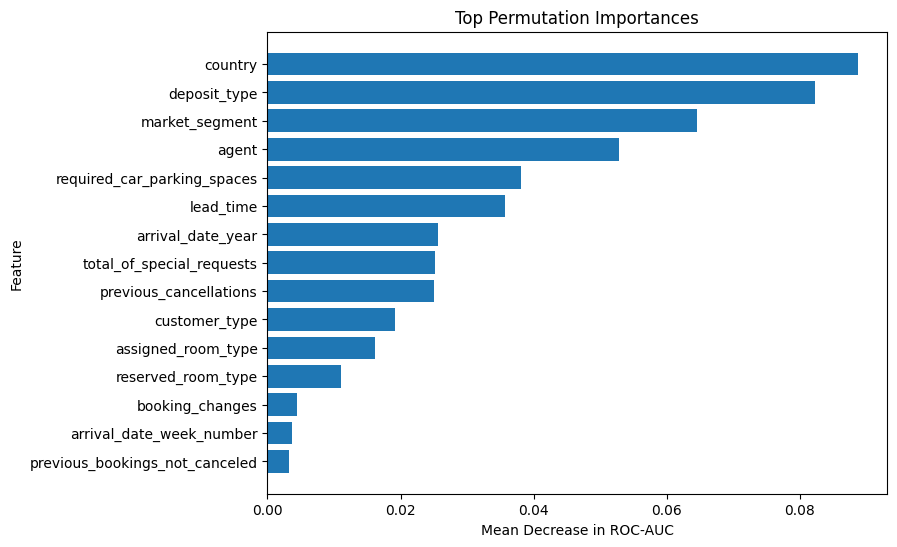

In [36]:
top_importance = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title("Top Permutation Importances")
plt.xlabel("Mean Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.show()

## Feature Importance

Permutation importance estimates how much each original feature contributes to model performance.

The method works by randomly shuffling one feature at a time and measuring how much the model score drops.

A larger decrease in ROC-AUC means the feature is more important for predicting cancellations.

The most important features were:

- `country`
- `deposit_type`
- `market_segment`
- `agent`
- `required_car_parking_spaces`
- `lead_time`
- `arrival_date_year`
- `total_of_special_requests`
- `previous_cancellations`
- `customer_type`

The strongest features suggest that cancellation risk is influenced by customer origin, booking conditions, sales channel, booking agent, parking needs, lead time, special requests, and previous cancellation behaviour.

This gives the model useful business interpretability because many of the important features are directly related to booking commitment and customer behaviour.

In [37]:
risk_df = X_test.copy()
risk_df["actual_canceled"] = y_test
risk_df["cancel_probability"] = y_proba

risk_df["risk_band"] = pd.qcut(
    risk_df["cancel_probability"],
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

risk_summary = (
    risk_df
    .groupby("risk_band")
    .agg(
        bookings=("actual_canceled", "count"),
        actual_cancellations=("actual_canceled", "sum"),
        cancellation_rate=("actual_canceled", "mean"),
        avg_predicted_probability=("cancel_probability", "mean")
    )
    .reset_index()
)

risk_summary

,risk_band,bookings,actual_cancellations,cancellation_rate,avg_predicted_probability
0,Very Low,4776,4,0.000838,0.003313
1,Low,4775,142,0.029738,0.043860
2,Medium,4776,990,0.207286,0.228242
3,High,4775,3045,0.637696,0.604585
4,Very High,4776,4664,0.976549,0.957542


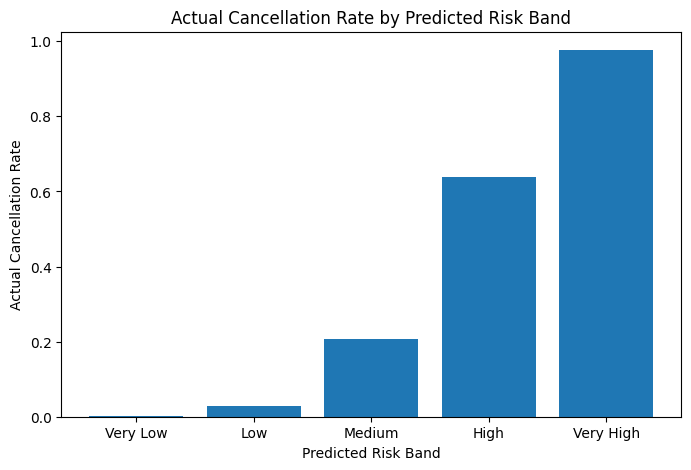

In [38]:
plt.figure(figsize=(8, 5))
plt.bar(risk_summary["risk_band"], risk_summary["cancellation_rate"])
plt.title("Actual Cancellation Rate by Predicted Risk Band")
plt.xlabel("Predicted Risk Band")
plt.ylabel("Actual Cancellation Rate")
plt.show()

## Risk Band Analysis

The predicted cancellation probabilities are grouped into five risk bands:

- Very Low
- Low
- Medium
- High
- Very High

This makes the model easier to interpret from a business perspective.

The actual cancellation rate increased strongly across the risk bands:

- Very Low: 0.08%
- Low: 2.97%
- Medium: 20.73%
- High: 63.77%
- Very High: 97.65%

The average predicted probability also increased clearly across the bands, from 0.0033 in the Very Low band to 0.9575 in the Very High band.

This shows that the model is very effective at ranking bookings by cancellation risk.

Instead of only outputting a 0 or 1 prediction, the model can help hotel managers identify which bookings are low-risk, medium-risk, or high-risk. This could support overbooking strategy, reminder communication, payment policy, and operational planning.

In [39]:
error_df = X_test.copy()
error_df["actual"] = y_test
error_df["predicted"] = y_pred
error_df["cancel_probability"] = y_proba

false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
].sort_values("cancel_probability", ascending=False)

false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
].sort_values("cancel_probability", ascending=True)

print("False positives:", false_positives.shape[0])
print("False negatives:", false_negatives.shape[0])

False positives: 1126
False negatives: 1745


In [40]:
false_positives.head(10)

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stay_nights,has_previous_cancellation,has_special_request,has_parking,actual,predicted,cancel_probability
14295,Resort Hotel,17,2016,December,50,10,1,1,2,1.0,0,BB,NaN,Direct,Direct,0,1,0,D,D,3,No Deposit,NaN,NaN,0,Transient,53.63,0,1,3.0,2,1,1,0,0,1,0.974544
39286,Resort Hotel,327,2017,August,31,4,2,7,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,240.0,NaN,0,Transient,174.80,0,1,2.0,9,0,1,0,0,1,0.940373
5677,Resort Hotel,203,2016,May,20,10,0,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,No Deposit,248.0,NaN,0,Transient-Party,46.00,0,0,2.0,2,0,0,0,0,1,0.919803
38547,Resort Hotel,72,2017,July,29,18,0,4,2,0.0,0,HB,ESP,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,271.00,0,0,2.0,4,0,0,0,0,1,0.918458
118127,City Hotel,215,2017,August,32,12,2,1,2,2.0,0,BB,MAR,Online TA,TA/TO,0,0,0,F,F,0,No Deposit,9.0,NaN,0,Transient,202.50,0,0,4.0,3,0,0,0,0,1,0.917976
36309,Resort Hotel,250,2017,May,19,7,4,5,2,0.0,0,BB,IRL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,54.00,0,0,2.0,9,0,0,0,0,1,0.917591
119058,City Hotel,301,2017,August,35,27,2,0,2,2.0,0,BB,GBR,Online TA,TA/TO,0,0,0,F,F,0,No Deposit,9.0,NaN,0,Transient,179.10,0,0,4.0,2,0,0,0,0,1,0.914879
38725,Resort Hotel,332,2017,July,29,22,2,4,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,154.38,0,2,2.0,6,0,1,0,0,1,0.913398
39330,Resort Hotel,197,2017,August,31,5,4,6,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,168.00,0,0,2.0,10,0,0,0,0,1,0.911464
33987,Resort Hotel,200,2017,February,7,17,6,15,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,E,E,0,No Deposit,75.0,NaN,0,Transient,66.60,0,0,2.0,21,0,0,0,0,1,0.910814


In [41]:
false_negatives.head(10)

,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,total_guests,total_stay_nights,has_previous_cancellation,has_special_request,has_parking,actual,predicted,cancel_probability
17123,Resort Hotel,212,2015,September,39,26,0,1,2,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,A,D,0,No Deposit,240.0,NaN,0,Transient-Party,74.70,0,2,2.0,1,0,1,0,1,0,0.004307
70258,City Hotel,22,2017,June,24,13,0,1,2,0.0,0,BB,LUX,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,28.0,NaN,0,Transient,99.00,0,0,2.0,1,0,0,0,1,0,0.004348
57409,City Hotel,35,2016,September,40,26,1,0,1,0.0,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,85.0,NaN,0,Transient,81.00,0,0,1.0,1,0,0,0,1,0,0.006419
55987,City Hotel,178,2016,August,35,26,0,2,2,1.0,0,BB,GBR,Offline TA/TO,TA/TO,0,0,0,E,E,0,No Deposit,83.0,NaN,0,Transient,117.60,0,0,3.0,2,0,0,0,1,0,0.007095
57028,City Hotel,0,2016,September,38,16,1,2,2,0.0,0,BB,CHE,Direct,Direct,0,0,0,A,K,0,No Deposit,14.0,NaN,0,Transient,78.80,0,0,2.0,3,0,0,0,1,0,0.009560
66734,City Hotel,109,2017,April,17,24,1,2,2,0.0,0,BB,AUT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,7.0,NaN,0,Transient,97.02,0,2,2.0,3,0,1,0,1,0,0.009691
54672,City Hotel,0,2016,July,30,23,0,1,1,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,D,A,0,No Deposit,9.0,NaN,0,Transient-Party,93.50,0,2,1.0,1,0,1,0,1,0,0.011092
73598,City Hotel,116,2017,August,35,27,1,0,3,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,7.0,NaN,0,Transient,185.25,0,3,3.0,1,0,1,0,1,0,0.011830
50336,City Hotel,36,2016,April,18,29,0,1,1,0.0,0,SC,USA,Offline TA/TO,GDS,0,0,0,A,A,0,No Deposit,195.0,NaN,0,Transient,111.60,0,0,1.0,1,0,0,0,1,0,0.011956
41088,City Hotel,0,2015,August,33,12,0,1,2,0.0,0,BB,FRA,Groups,TA/TO,0,0,0,A,A,0,No Deposit,1.0,NaN,0,Transient,62.80,0,0,2.0,1,0,0,0,1,0,0.012469


## Error Analysis

Error analysis helps explain where the model makes mistakes.

The model produced:

- 1,126 false positives
- 1,745 false negatives

False positives are bookings that were predicted as cancelled but were not actually cancelled.

False negatives are bookings that were predicted as not cancelled but were actually cancelled.

In a hotel setting, false negatives may be costly because the hotel fails to identify bookings that are likely to cancel. This can affect room planning, revenue management, and overbooking decisions.

False positives may also have a cost because the hotel may treat a reliable booking as risky.

The balance between false positives and false negatives depends on the business goal. If the hotel wants to catch as many cancellations as possible, a lower threshold such as 0.40 may be preferred. If the hotel wants fewer false alarms, a higher threshold may be preferred.